# Pocket & Ligand Visualization — Same PDB ID

Identifies benchmark samples where the **receptor pocket and ligand originate from the
same PDB entry** (self-docking cases, as opposed to cross-docked pairs).

| Section | What it shows |
|---|---|
| Same-PDB statistics | Sample counts per receptor PDB ID |
| 3D overlay | All pocket + ligand poses for a selected PDB ID |
| Ligand centroid spread | Spatial diversity of docked ligands |

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import torch
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from collections import Counter
from pathlib import Path

from voxbind.constants import ELEMENTS_HASH_CROSSDOCKED

DATA_DIR = Path("..") / "voxbind" / "dataset" / "data"
IDX_TO_ELEM = {v: k for k, v in ELEMENTS_HASH_CROSSDOCKED.items()}

# Atom colours (pocket = by channel, ligand = by element)
POCKET_COLORS = {0: "silver", 1: "salmon", 2: "cornflowerblue", 3: "khaki"}
LIGAND_COLORS = {0: "gray", 1: "red", 2: "blue", 3: "gold",
                 4: "green", 5: "lime", 6: "orange"}

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

## 1. Load Benchmark & Identify Same-PDB Samples

In [ ]:
def get_poc_pdb(pocket_id: str) -> str:
    """Receptor PDB ID — first token of the filename."""
    return pocket_id.split("/")[1].split("_")[0].lower()

def get_lig_pdb(pocket_id: str) -> str:
    """Ligand's original PDB ID — first token after '_rec_' in the filename."""
    fname = pocket_id.split("/")[1]           # e.g. '14gs_A_rec_20gs_cbd_lig_...'
    parts = fname.split("_rec_")
    return parts[1].split("_")[0].lower() if len(parts) > 1 else None

# Load all splits
all_samples = []
for fname in ("data_train.pt", "data_test.pt"):
    data = torch.load(DATA_DIR / fname, weights_only=False)
    all_samples.extend(data)
    print(f"  {fname}: {len(data):,} samples")

# Partition into same-PDB vs cross-docked
same_pdb  = [(p, l) for p, l in all_samples if get_poc_pdb(p["id"]) == get_lig_pdb(p["id"])]
cross_pdb = [(p, l) for p, l in all_samples if get_poc_pdb(p["id"]) != get_lig_pdb(p["id"])]

print(f"\nTotal samples            : {len(all_samples):,}")
print(f"Same-PDB (self-docking)  : {len(same_pdb):,}  ({100*len(same_pdb)/len(all_samples):.1f}%)")
print(f"Cross-docked             : {len(cross_pdb):,}  ({100*len(cross_pdb)/len(all_samples):.1f}%)")

# Unique pocket PDB IDs across splits
all_poc_pdbs   = set(get_poc_pdb(p["id"]) for p, _ in all_samples)
same_poc_pdbs  = set(get_poc_pdb(p["id"]) for p, _ in same_pdb)
cross_poc_pdbs = set(get_poc_pdb(p["id"]) for p, _ in cross_pdb)

print(f"\nUnique pocket PDB IDs:")
print(f"  All samples    : {len(all_poc_pdbs):,}")
print(f"  Same-PDB       : {len(same_poc_pdbs):,}")
print(f"  Cross-docked   : {len(cross_poc_pdbs):,}")

## 2. Same-PDB Sample Count per Receptor PDB ID

Unique receptor PDB IDs (same-PDB) : 8,744
Average # same-PDB samples per receptor: 1.6
Top 10:
  2q3t: 60
  4fr8: 14
  3cmp: 12
  4cpp: 10
  3luh: 10
  3g4q: 9
  4ajj: 9
  3ujs: 8
  2ipo: 8
  1p7l: 7


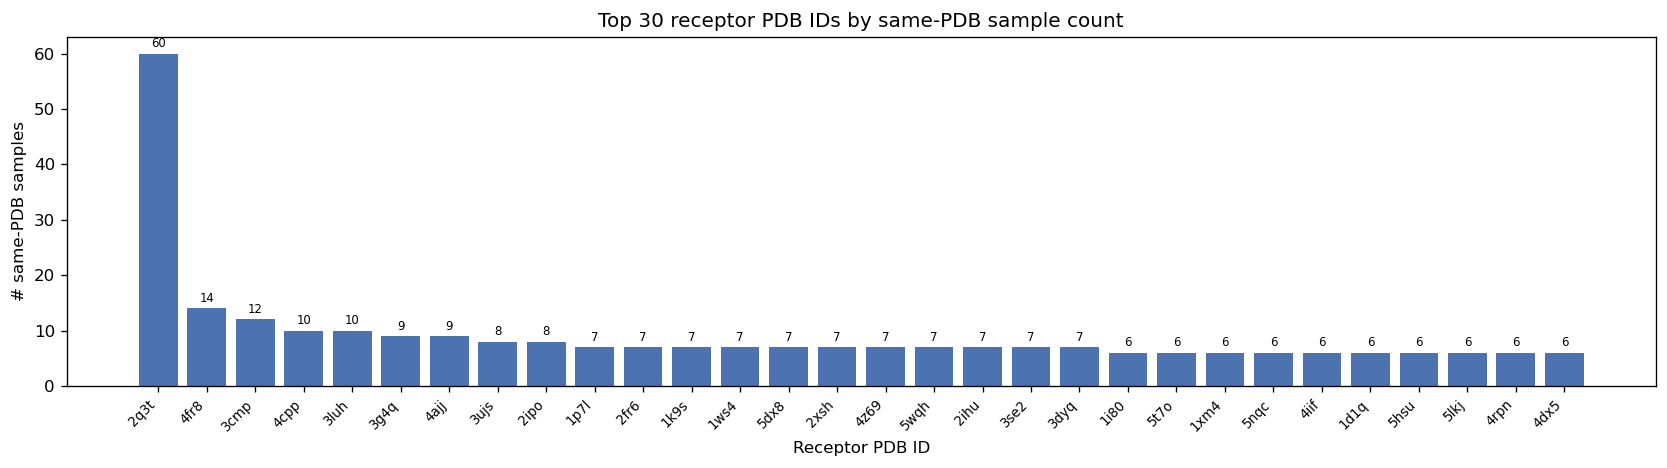

In [7]:
poc_counts = Counter(get_poc_pdb(p["id"]) for p, _ in same_pdb)
top_n = 30
top_pdbs, top_counts = zip(*poc_counts.most_common(top_n))

print(f"Unique receptor PDB IDs (same-PDB) : {len(poc_counts):,}")
print(f"Average # same-PDB samples per receptor: {sum(poc_counts.values()) / len(poc_counts):.1f}")
print(f"Top 10:")
for pdb, n in poc_counts.most_common(10):
    print(f"  {pdb}: {n}")

fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(top_pdbs, top_counts, color="#4C72B0")
ax.bar_label(bars, padding=2, fontsize=7)
ax.set_xlabel("Receptor PDB ID")
ax.set_ylabel("# same-PDB samples")
ax.set_title(f"Top {top_n} receptor PDB IDs by same-PDB sample count")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

## 3. Select PDB ID & Collect Samples

`TARGET_PDB` is set to the receptor with the most same-PDB samples.

In [4]:
TARGET_PDB = poc_counts.most_common(1)[0][0]   # change to any PDB ID you like

target_samples = [(p, l) for p, l in same_pdb
                  if get_poc_pdb(p["id"]) == TARGET_PDB]

print(f"Target PDB  : {TARGET_PDB.upper()}")
print(f"Samples     : {len(target_samples)}")

# Show the sample IDs
print("\nSample list:")
for i, (p, l) in enumerate(target_samples):
    print(f"  [{i:2d}] pocket: {p['id'].split('/')[1]}")
    print(f"       ligand: {l['id'].split('/')[1]}")

Target PDB  : 2Q3T
Samples     : 60

Sample list:
  [ 0] pocket: 2q3t_A_rec_2q3t_cps_lig_tt_docked_278_pocket10.pdb
       ligand: 2q3t_A_rec_2q3t_cps_lig_tt_docked_278.sdf
  [ 1] pocket: 2q3t_A_rec_2q3t_cps_lig_tt_docked_85_pocket10.pdb
       ligand: 2q3t_A_rec_2q3t_cps_lig_tt_docked_85.sdf
  [ 2] pocket: 2q3t_A_rec_2q3t_cps_lig_tt_docked_246_pocket10.pdb
       ligand: 2q3t_A_rec_2q3t_cps_lig_tt_docked_246.sdf
  [ 3] pocket: 2q3t_A_rec_2q3t_cps_lig_tt_docked_0_pocket10.pdb
       ligand: 2q3t_A_rec_2q3t_cps_lig_tt_docked_0.sdf
  [ 4] pocket: 2q3t_A_rec_2q3t_cps_lig_tt_docked_135_pocket10.pdb
       ligand: 2q3t_A_rec_2q3t_cps_lig_tt_docked_135.sdf
  [ 5] pocket: 2q3t_A_rec_2q3t_cps_lig_tt_docked_115_pocket10.pdb
       ligand: 2q3t_A_rec_2q3t_cps_lig_tt_docked_115.sdf
  [ 6] pocket: 2q3t_A_rec_2q3t_cps_lig_tt_docked_49_pocket10.pdb
       ligand: 2q3t_A_rec_2q3t_cps_lig_tt_docked_49.sdf
  [ 7] pocket: 2q3t_A_rec_2q3t_cps_lig_tt_docked_189_pocket10.pdb
       ligand: 2q3t_A_rec_2q3t_

## 4. 3D Overlay — All Pocket & Ligand Poses

In [5]:
# Palette for different ligand samples
import plotly.express as px
palette = px.colors.qualitative.Plotly + px.colors.qualitative.Safe

traces = []

# ── Pocket: aggregate all atoms from all samples ───────────────────────────
poc_ch_to_coords = {}
for p, _ in target_samples:
    mask = p["atoms_channel"] < 4
    coords   = p["coords"][mask].numpy()
    channels = p["atoms_channel"][mask].numpy()
    for ch in np.unique(channels):
        poc_ch_to_coords.setdefault(int(ch), []).append(coords[channels == ch])

min_ch = min(poc_ch_to_coords)
for ch, coord_list in sorted(poc_ch_to_coords.items()):
    xyz = np.concatenate(coord_list, axis=0)
    elem = IDX_TO_ELEM.get(ch, f"ch{ch}")
    traces.append(go.Scatter3d(
        x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2],
        mode="markers",
        marker=dict(size=2.5, color=POCKET_COLORS.get(ch, "white"), opacity=0.18),
        name=f"Pocket {elem}",
        legendgroup="pocket",
        showlegend=bool(ch == min_ch),
    ))

# ── Ligands: one colour per sample ────────────────────────────────────────
for i, (p, l) in enumerate(target_samples):
    mask = l["atoms_channel"] < 7
    coords = l["coords"][mask].numpy()
    color  = palette[i % len(palette)]
    label  = l["id"].split("/")[1].replace(".sdf", "")
    traces.append(go.Scatter3d(
        x=coords[:, 0], y=coords[:, 1], z=coords[:, 2],
        mode="markers",
        marker=dict(size=5, color=color, opacity=0.85,
                    line=dict(width=0.5, color="white")),
        name=label,
        legendgroup=f"lig_{i}",
    ))

fig = go.Figure(traces)
fig.update_layout(
    title=f"{TARGET_PDB.upper()} — {len(target_samples)} same-PDB pocket/ligand overlays",
    scene=dict(
        xaxis_title="X (\u00c5)",
        yaxis_title="Y (\u00c5)",
        zaxis_title="Z (\u00c5)",
        aspectmode="data",
    ),
    width=950, height=700,
    legend=dict(itemsizing="constant", font=dict(size=9)),
)
fig.show()

## 5. Ligand Centroid Spread

In [6]:
centroids = []
for p, l in target_samples:
    mask = l["atoms_channel"] < 7
    coords = l["coords"][mask].numpy()
    centroids.append(coords.mean(axis=0))
centroids = np.array(centroids)   # (N, 3)

# pairwise distances between centroids
from scipy.spatial.distance import pdist
dists = pdist(centroids)

fig2 = go.Figure()

# Pocket cloud (first sample, for reference)
p0, _ = target_samples[0]
poc_mask = p0["atoms_channel"] < 4
poc_xyz  = p0["coords"][poc_mask].numpy()
fig2.add_trace(go.Scatter3d(
    x=poc_xyz[:, 0], y=poc_xyz[:, 1], z=poc_xyz[:, 2],
    mode="markers",
    marker=dict(size=2, color="silver", opacity=0.15),
    name="Pocket (ref)",
))

# Centroids coloured by index
fig2.add_trace(go.Scatter3d(
    x=centroids[:, 0], y=centroids[:, 1], z=centroids[:, 2],
    mode="markers+text",
    marker=dict(
        size=8,
        color=list(range(len(centroids))),
        colorscale="Viridis",
        showscale=True,
        colorbar=dict(title="sample idx", thickness=12, len=0.6),
        opacity=0.9,
    ),
    text=[str(i) for i in range(len(centroids))],
    textposition="top center",
    textfont=dict(size=7),
    name="Ligand centroids",
))

fig2.update_layout(
    title=f"{TARGET_PDB.upper()} — ligand centroid spread",
    scene=dict(
        xaxis_title="X (\u00c5)",
        yaxis_title="Y (\u00c5)",
        zaxis_title="Z (\u00c5)",
        aspectmode="data",
    ),
    width=800, height=600,
)
fig2.show()

print(f"Ligand centroid spread ({len(centroids)} poses):")
print(f"  Mean pairwise distance : {dists.mean():.2f} \u00c5")
print(f"  Max  pairwise distance : {dists.max():.2f} \u00c5")
print(f"  Min  pairwise distance : {dists.min():.2f} \u00c5")

Ligand centroid spread (60 poses):
  Mean pairwise distance : 1.90 Å
  Max  pairwise distance : 5.43 Å
  Min  pairwise distance : 0.09 Å
